In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression

from math import *
from scipy.stats import norm

In [2]:
data = pd.read_csv("./spx_quotedata.csv",
        sep=',',
        index_col=False,
		header=0
	)

In [3]:
data = pd.read_csv("./sp-index.txt",
        sep='\t',
        index_col=False,
		header=0
	)

In [4]:
data.head()

,T,K,Cb,Ca,Pb,Pa,r
0,0.083333,800,459.6,461.6,0.0,0.25,4.6
1,0.083333,850,409.8,411.8,0.0,0.25,4.6
2,0.083333,900,360.0,362.0,0.0,0.50,4.6
3,0.083333,950,310.3,312.3,0.1,0.20,4.6
4,0.083333,1000,260.5,262.5,0.1,0.50,4.6


In [5]:
T = np.unique(data["T"])

In [6]:
S_values = []

for t in T:

    data_t = data[data["T"]==t].reset_index()
    N = len(data_t)
    S=0
    for i in range(0,N):
        call_M = ( data_t["Cb"][i] + data_t["Ca"][i] ) /2
        put_M = ( data_t["Pb"][i] + data_t["Pa"][i] ) /2
        K = data_t["K"][i]
        r = data_t["r"][i]/100
        S += call_M - put_M + np.exp(-r*t)*K

    S_values.append(np.log(S/N))


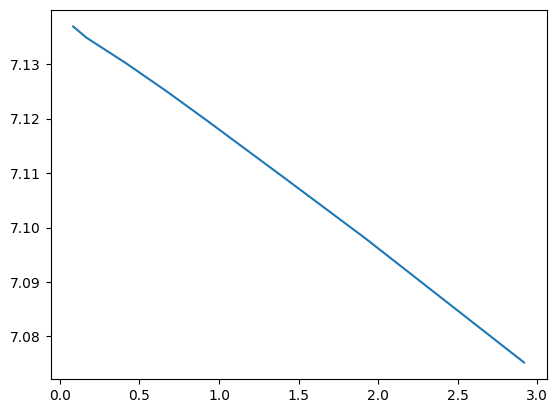

In [7]:
plt.figure()
plt.plot(T,S_values)

In [8]:

X = T.reshape(-1, 1)
model = LinearRegression()
model.fit(X, S_values)

print(f"Taux de dividende q = {-model.coef_[0]}")
print(f"Prix S0 = {np.exp(model.intercept_)}")

Taux de dividende q = 0.02166466966128491
Prix S0 = 1260.3666787091668


# Drawing skew

In [9]:
def F_Newton(S0, K, T, r, V_marche, sigma):
    d1 = ( np.log(S0/K) + (r+pow(sigma,2)/2)*T ) / (sigma*sqrt(T))
    d2 = ( np.log(S0/K) + (r-pow(sigma,2)/2)*T ) / (sigma*sqrt(T))
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2) - V_marche

def Vega_BS(S0, K, r, T, sigma):
    d1 = ( np.log(S0/K) + (r+pow(sigma,2)/2)*T ) / (sigma*sqrt(T))
    return S0*sqrt(T/(2*pi))*np.exp(-pow(d1,2)/2)




def vol_implicite(S0, K, T, r, V_marche, epsilon=0.001):

    sigma = sqrt(2*abs( (np.log(S0/K) + r*T)/T ))

    if max(S0-K*np.exp(-r*T),0) < V_marche and V_marche < S0:

        while abs(F_Newton(S0, K, T, r, V_marche, sigma)) > epsilon:              
            sigma = sigma - F_Newton(S0, K, T, r, V_marche, sigma)/Vega_BS(S0, K, r, T, sigma)

        return sigma
    
    else:
        return 0

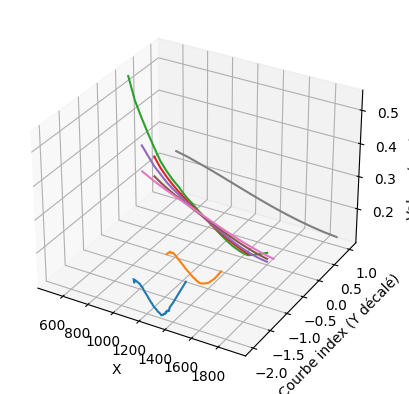

In [34]:
# on a encore des 0 parce que certains prix ne respectent pas le marché AOA

#prepare la figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

implied_vol = []
#K = np.unique(data["K"])
T = np.unique(np.round(data["T"], 6))
for t in T:

    S0 = np.exp(model.intercept_)*np.exp(model.coef_[0]*t) #S0 actualise aux dividendes
    data_t = data[np.round(data["T"], 6)==t].reset_index()
    K = np.unique(data_t[np.round(data_t["T"], 6)==t]["K"])
    vol_t = []
    for k in K:
        if not data_t[data_t["K"]==k]["K"].empty :
            V_marche = (data_t[data_t["K"]==k]["Cb"].iloc[0] + data_t[data_t["K"]==k]["Ca"].iloc[0]) /2
            r = float(data_t[data_t["K"]==k]["r"].iloc[0])*0.01
            vol_t.append(vol_implicite(S0, k, t, r, V_marche, epsilon=0.001))

        else:
            vol_t.append(0)

    vol_0 = np.array(vol_t)!=0
    K = K[vol_0]
    vol_t = np.array(vol_t)[vol_0]
    implied_vol.append(vol_t)
    ax.plot(K, np.full_like(K, np.log(t)), vol_t)


ax.set_xlabel("X")
ax.set_ylabel("Courbe index (Y décalé)")
ax.set_zlabel("Valeur (ancien Y)")

plt.show()



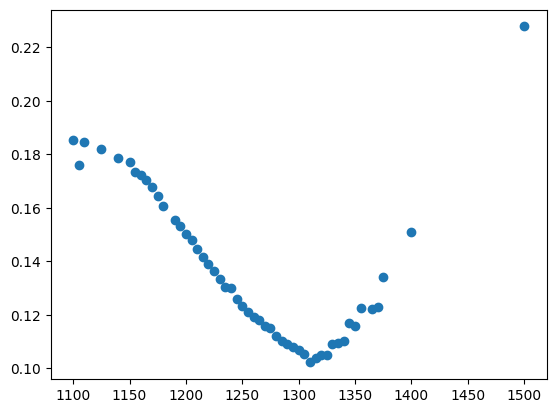

In [36]:
T = np.unique(np.round(data["T"], 6))
t = T[0]
S0 = np.exp(model.intercept_)*np.exp(model.coef_[0]*t) #S0 actualise aux dividendes
data_t = data[np.round(data["T"], 6)==t].reset_index()
K = np.unique(data_t[np.round(data_t["T"], 6)==t]["K"])
vol_t = []

for k in K:
    if not data_t[data_t["K"]==k]["K"].empty :
        V_marche = (data_t[data_t["K"]==k]["Cb"].iloc[0] + data_t[data_t["K"]==k]["Ca"].iloc[0]) /2
        r = float(data_t[data_t["K"]==k]["r"].iloc[0])*0.01
        vol_t.append(vol_implicite(S0, k, t, r, V_marche, epsilon=0.001))

    else:
        vol_t.append(0)

vol_0 = np.array(vol_t)!=0
K = K[vol_0]
vol_t = np.array(vol_t)[vol_0]
plt.scatter(K, vol_t)